# Global Stuffs

In [4]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
import h5py
import re

## functions

In [5]:
def set_plot_style(axs, fonts, xlabel, ylabel):
    axs.set_xlabel(xlabel, fontsize=fonts)
    axs.set_ylabel(ylabel, fontsize=fonts)
    axs.tick_params(axis='both', which='major', direction='out', length=4, width=1)
    axs.tick_params(which='minor', width=1, size=2)  # Adjust size as needed
    axs.minorticks_on() # Turn on minor ticks
    
    #axs.grid(False, which='both', axis='both', linestyle='--', linewidth=0.5)
    axs.set_facecolor('white')
    axs.spines['top'].set_linewidth(1)
    axs.spines['right'].set_linewidth(1)
    axs.spines['bottom'].set_linewidth(1)
    axs.spines['left'].set_linewidth(1)
    axs.tick_params(axis='x', labelsize=fonts)
    axs.tick_params(axis='y', labelsize=fonts)

    return axs

def darken_colors(num_colors, darker_factor=0.7):
    colors = plt.cm.jet(np.linspace(0, 1, num_colors))
    darker_colors = colors.copy()

    for i in range(num_colors):
        rgb = darker_colors[i, :3]
        hsv = plt.cm.colors.rgb_to_hsv(rgb)
        hsv[2] *= darker_factor
        darker_colors[i, :3] = plt.cm.colors.hsv_to_rgb(hsv)

    return darker_colors


def create_label(filename):
    # Only modify if any target patterns exist
    if any(x in filename for x in ['thresh1_', 'f_', 'azimuthal', 'P3HB', 'rep_', '_01', 'subtracted_avg_']):
        label = filename.split('.')[0]
        label = label.replace('thresh1_', '').split('_Scan')[0]
        label = label.split('f_')[-1] if 'f_' in label else label
        label = label.split('_azimuthal')[0] if 'azimuthal' in label else label
        label = label.replace('P3HB', 'PHA-3B')
        label = label.replace('rep_', '').replace('_01', '')
        label = label.replace('subtracted_avg_', '')
    else:
        label = filename.split('.')[0]  # just remove extension, no other changes
    return label


## read and plot excel files

# tensile function

Property: Strain
Start time: 2025-05-24 13:38:02.988610
                      time  Strain
2025-05-24 13:38:02.988610     0.0
2025-05-24 13:38:03.247850     0.0
2025-05-24 13:38:03.507080     0.0
2025-05-24 13:38:03.766320     0.0
2025-05-24 13:38:04.025560     0.0


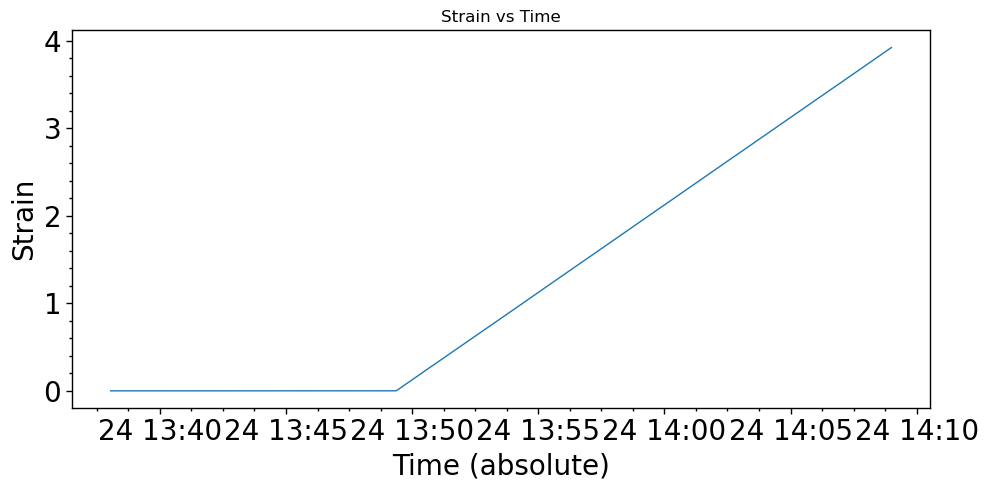

In [6]:
from isort import file
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

def load_linkam_xy_end_ref(file_path, file_name, property_name, sheet_name=0):
    full_path = str(Path(file_path) / file_name)
    df_raw = pd.read_excel(full_path, sheet_name=sheet_name, header=None)  # end-ref uses same source

    # Recorded = END of measurement
    rec_idx = df_raw.apply(lambda r: r.astype(str).str.contains('^Recorded:', case=False, regex=True).any(), axis=1).idxmax()
    rec_cells = df_raw.loc[rec_idx].dropna().astype(str)
    rec_text = next(x for x in rec_cells if x.lower().startswith('recorded:'))
    end_dt = pd.to_datetime(rec_text.split(':', 1)[1].strip())

    # Find two-row header: property names above, then a row starting with "Index"
    idx_row = df_raw.index[df_raw.iloc[:, 0].astype(str).str.strip().eq('Index')]
    if len(idx_row) == 0:
        raise ValueError("Could not find 'Index' row that defines X/Y columns.")
    header_bottom = idx_row[0]
    header_top = header_bottom - 1

    top = df_raw.iloc[header_top].astype(str).str.strip().tolist()
    bot = df_raw.iloc[header_bottom].astype(str).str.strip().tolist()

    # Forward-fill property names; set first column to Index
    filled_top, cur = [], ''
    for v in top:
        if v and v.lower() != 'nan':
            cur = v
        filled_top.append(cur)
    if bot[0].lower() == 'index':
        filled_top[0] = 'Index'

    labels = []
    for j, (p, s) in enumerate(zip(filled_top, bot)):
        prop = p if p else f'Col{j}'
        sub = s if s and s.lower() != 'nan' else 'Y'
        if j == 0 and sub.lower() == 'index':
            sub = 'Index'
        labels.append((prop, sub))
    columns = pd.MultiIndex.from_tuples(labels, names=['Property', 'Sub'])

    # Data body
    df = df_raw.iloc[header_bottom + 1:].copy()
    df.columns = columns

    # Pick property (case-insensitive, ignore spaces)
    norm = property_name.replace(' ', '').lower()
    props = {p.replace(' ', '').lower(): p for p in df.columns.get_level_values(0).unique()}
    if norm not in props:
        raise ValueError(f"Property '{property_name}' not found; available: {sorted(props.values())}")

    prop = props[norm]
    if (prop, 'X') not in df.columns or (prop, 'Y') not in df.columns:
        raise ValueError(f"Expected X/Y columns for '{prop}' not found in header.")

    # Durations in seconds for this property
    t_sec = pd.to_numeric(df[(prop, 'X')], errors='coerce')
    y_vals = pd.to_numeric(df[(prop, 'Y')], errors='coerce')
    mask = t_sec.notna()
    t_sec = t_sec[mask]
    y_vals = y_vals[mask]

    # Align end-of-run: final time equals Recorded
    t_max = t_sec.max()
    x_abs = end_dt + pd.to_timedelta(t_sec - t_max, unit='s')

    return x_abs, y_vals, prop

# Example usage
if __name__ == "__main__":
    file_path = "."
    #file_name = "Run5_LDPE_50C_50ums-24-05-25 13-30-01-20Exported.xlsx"
    file_name = "Run6_LDPE_75C_50ums 24-05-25 14-09-03-47Exported.xlsx"
    prop = "Strain"





# --- Configure and run ---
#file_path = '.'  # change to the directory containing the Excel if needed
file_path = r"/Users/akmaurya/OneDrive - Stanford/Data_01/Redesigned_Plastics/May_2025/linkam_stage/tensile_temperature_data"  # Example fixed path
    
#file_name = 'Run5_LDPE_50C_50ums 24-05-25 13-30-01-20Exported.xlsx'
#property_to_plot = 'Strain'  # Case-insensitive


prop = "Strain"  # e.g., 'Strain', 'Stress', 'Temperature', 'Force', 'Distance', 'Gap', 'Rh', 'Rhtemp', etc.

x_time, y_values, prop_name = load_linkam_xy_end_ref(file_path, file_name, prop)

#print(x_time)



print("Property:", prop_name)
print("Start time:", x_time.iloc[0])
print(pd.DataFrame({"time": x_time.head(5), prop_name: y_values.head(5)}).to_string(index=False))  # [attached_file:2]

plt.figure(figsize=(10, 5))
plt.plot(x_time, y_values, lw=1)
plt.xlabel("Time (absolute)")
plt.ylabel(prop_name)
set_plot_style(plt.gca(), 20, "Time (absolute)", prop_name)
plt.title(f"{prop_name} vs Time")
plt.tight_layout()
plt.show()  # [attached_file:2]



## waxs crytallinity paramter

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import os

def extract_WAXS_crystallinity_parameters(folder_path, filename):
    """
    Reads a specific Excel file, extracts each column (except the first datetime column),
    returns them as a dictionary where keys are column names, and plots each column individually.

    Parameters:
    folder_path (str): Path to the folder containing Excel files.
    filename (str): Specific Excel file to process.

    Returns:
    dict: A dictionary with column names as keys and Pandas Series as values.
    """
    column_data = {}

    file_path = os.path.join(folder_path, filename)
    if not (os.path.exists(file_path) and filename.endswith((".xlsx", ".xls"))):
        print(f"❌ File not found or not an Excel file: {filename}")
        return column_data

    print(f"\n📂 Processing file: {filename}")
    try:
        df = pd.read_excel(file_path)

        # Convert first column to datetime and set as index
        df.iloc[:, 0] = pd.to_datetime(df.iloc[:, 0], errors='coerce')
        df.dropna(subset=[df.columns[0]], inplace=True)
        df.set_index(df.columns[0], inplace=True)

       
        # Extract each column as Series and store with its name
        for col in df.columns:
            series = df[col]
            column_data[col] = series
            '''
            # Plot each column
            plt.figure(figsize=(10, 4))
            plt.plot(series.index, series.values, label=col)
            plt.xlabel("Time")
            plt.ylabel(col)
            plt.title(f"{col} vs Time")
            plt.grid(True)
            plt.tight_layout()
            plt.legend()
            plt.show()
        '''
    except Exception as e:
        print(f"❌ Failed to process {filename}: {e}")

    return column_data




## Orientation Function

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import os

def extract_WAXS_orientation_parameters(folder_path, filename):
    """
    Reads an Excel file containing WAXS orientation parameters (no timestamp),
    and returns each column as a Series in a dictionary.

    Parameters:
    folder_path (str): Path to the folder containing the Excel file.
    filename (str): The Excel file name.

    Returns:
    dict: A dictionary where keys are column names and values are Pandas Series.
    """
    column_data = {}

    file_path = os.path.join(folder_path, filename)
    if not (os.path.isfile(file_path) and filename.lower().endswith((".xlsx", ".xls"))):
        print(f"❌ File not found or not an Excel file: {filename}")
        return column_data

    print(f"\n📂 Processing file: {filename}")
    try:
        # Read the Excel file as a regular DataFrame (no datetime parsing)
        df = pd.read_excel(file_path)

        # Store each column as a Series in the dictionary
        for col in df.columns:
            column_data[col] = df[col]

            # Optional: Uncomment below to plot each column
            # plt.figure(figsize=(8, 4))
            # plt.plot(df[col], label=col)
            # plt.xlabel("Frame Index")
            # plt.ylabel(col)
            # plt.title(f"{col} vs Frame")
            # plt.grid(True)
            # plt.legend()
            # plt.tight_layout()
            # plt.show()

    except Exception as e:
        print(f"❌ Failed to process {filename}: {e}")

    return column_data


## merge scans #1 , #2, #3

In [9]:
import pandas as pd
import glob
import os
from concurrent.futures import ThreadPoolExecutor

folder_path = '/Volumes/SSD1/RawData1/Redesigned_Plastics/May2025/2025_05_Anjani/OneD_integrated_WAXS_01/Subtracted_Data/Final_analysis/'

# Combine all runs into a single list
runs = [
    "crystallinity_subtracted_Run5_LDPE_50C_50ums",
    "crystallinity_subtracted_Run6_LDPE_75C_50ums",
    "crystallinity_subtracted_Run7_LDPE_100C_50ums",
    "crystallinity_subtracted_Run8_LDPE_30C_50ums",
    "orientation_Run5_LDPE_50C_50ums",
    "orientation_Run6_LDPE_75C_50ums",
    "orientation_Run7_LDPE_100C_50ums",
    "orientation_Run8_LDPE_30C_50ums",
    "crystallinity_subtracted_Run9_PHPD_30C_50ums",
    "crystallinity_subtracted_Run10_PHPD_45C_50ums",
    "crystallinity_subtracted_Run11_PHPD_60C_50ums",
    "crystallinity_subtracted_Run12_PHPD_75C_50ums",
    "orientation_Run9_PHPD_30C_50ums",
    "orientation_Run10_PHPD_45C_50ums",
    "orientation_Run11_PHPD_60C_50ums",
    "orientation_Run12_PHPD_75C_50ums"
]

scans = ["scan001", "scan002", "scan003"]

def merge_scans_for_run(run):
    # Get scan001 as the base
    pattern_scan1 = os.path.join(folder_path, f"*{run}_scan001*.xlsx")
    base_file = glob.glob(pattern_scan1)
    if not base_file:
        print(f"Scan001 not found for {run}, skipping...")
        return

    merged_df = pd.read_excel(base_file[0])

    # Append scan002 and scan003
    for scan in ["scan002", "scan003"]:
        pattern = os.path.join(folder_path, f"*{run}_{scan}*.xlsx")
        for file in glob.glob(pattern):
            df = pd.read_excel(file)
            # Keep only the columns from base_file
            df = df[merged_df.columns]
            merged_df = pd.concat([merged_df, df], ignore_index=True)

    # Save merged file for this run
    out_file = os.path.join(folder_path, f"{run}_merged_scans.xlsx")
    merged_df.to_excel(out_file, index=False)
    print(f"Merged file saved for {run} as {out_file}")


# Run all merges in parallel
with ThreadPoolExecutor() as executor:
    executor.map(merge_scans_for_run, runs)


Merged file saved for orientation_Run9_PHPD_30C_50ums as /Volumes/SSD1/RawData1/Redesigned_Plastics/May2025/2025_05_Anjani/OneD_integrated_WAXS_01/Subtracted_Data/Final_analysis/orientation_Run9_PHPD_30C_50ums_merged_scans.xlsxMerged file saved for orientation_Run5_LDPE_50C_50ums as /Volumes/SSD1/RawData1/Redesigned_Plastics/May2025/2025_05_Anjani/OneD_integrated_WAXS_01/Subtracted_Data/Final_analysis/orientation_Run5_LDPE_50C_50ums_merged_scans.xlsx

Merged file saved for crystallinity_subtracted_Run8_LDPE_30C_50ums as /Volumes/SSD1/RawData1/Redesigned_Plastics/May2025/2025_05_Anjani/OneD_integrated_WAXS_01/Subtracted_Data/Final_analysis/crystallinity_subtracted_Run8_LDPE_30C_50ums_merged_scans.xlsx
Merged file saved for orientation_Run12_PHPD_75C_50ums as /Volumes/SSD1/RawData1/Redesigned_Plastics/May2025/2025_05_Anjani/OneD_integrated_WAXS_01/Subtracted_Data/Final_analysis/orientation_Run12_PHPD_75C_50ums_merged_scans.xlsx
Merged file saved for orientation_Run11_PHPD_60C_50ums as /V

# combine plot

In [10]:
folder_path_waxs = '/Volumes/SSD1/RawData1/Redesigned_Plastics/May2025/2025_05_Anjani/OneD_integrated_WAXS_01/Subtracted_Data/Final_analysis/'

#file_path_tensile = r"/Users/akmaurya/OneDrive - Stanford/Data_01/Redesigned_Plastics/Dec_2024/Anjani/Redesigned_Plastics/Dec2024_BL172/TS600_Scripts"  # Example fixed path

file_path_tensile = r"/Users/akmaurya/OneDrive - Stanford/Data_01/Redesigned_Plastics/May_2025/linkam_stage/tensile_temperature_data"  # Example fixed path


In [11]:
from math import pi
import time
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.dates as mdates
import os
import re
import numpy as np
from scipy.interpolate import interp1d
from matplotlib.ticker import FormatStrFormatter
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

def plot_waxs_with_tensile_overlay(
    folder_path_waxs, filename_waxs, filename_waxs_orientation,
    file_path_tensile, filename_tensile,
    vertical_line_time_str,
    yield_point_time_str=None,    # input for yield point time (string or datetime)
    fonts=16,
    time_mode='absolute',  # 'absolute' or 'relative'
    time_regions=None,     # list of (start_time, end_time, label, color)
    y_axis_limits=None     # list of (min, max) for each subplot
):
    # Load data
    crystallinity_data = extract_WAXS_crystallinity_parameters(folder_path_waxs, filename=filename_waxs)
    orientation_data = extract_WAXS_orientation_parameters(folder_path_waxs, filename=filename_waxs_orientation)
    #x_time, x_elongation, force = plot_measured_data(file_path_tensile, filename_tensile, y_column="stress")
    prop = "Stress"  # e.g., 'Strain', 'Stress', 'Temperature', 'Force', 'Distance', 'Gap', 'Rh', 'Rhtemp', etc.
    x_time, Stress, prop_name = load_linkam_xy_end_ref(file_path_tensile, filename_tensile, prop)

    prop = "Strain"  # e.g., 'Strain', 'Stress', 'Temperature', 'Force', 'Distance', 'Gap', 'Rh', 'Rhtemp', etc.
    x_time, Strain, prop_name = load_linkam_xy_end_ref(file_path_tensile, filename_tensile, prop)
    #force = force * 0.000001  # Convert force to MPa

    # Extract WAXS parameters
    date_time = crystallinity_data['percentage_crystallinity'].index
    crystallinity = crystallinity_data['percentage_crystallinity']
    size = crystallinity_data['crystallite_size']
    size = 0.9 * (1.0 / np.array(size)) * 2 * pi  # convert to peak position

    d_spacing = crystallinity_data['d_spacing']
    d_spacing = 2 * pi / d_spacing  # convert d-spacing to peak position

    peak_orientation = orientation_data.get('peak_position_orient')
    fwhm_orientation = orientation_data.get('peak_fwhm_orient')
    DOO = (180 - fwhm_orientation) / 180

    if peak_orientation is None or fwhm_orientation is None:
        raise KeyError("Orientation data missing required columns 'peak_position_orient' or 'peak_fwhm_orient'")
    if len(peak_orientation) != len(date_time):
        raise ValueError("Orientation data length does not match crystallinity data length")

    vertical_line_time = pd.to_datetime(vertical_line_time_str)
    force_color = 'gray'
    base_time = date_time[0]

    # Convert times to relative minutes if needed
    if time_mode == 'relative':
        def to_minutes(t): return (t - base_time).total_seconds() / 60

        date_time = pd.to_datetime(date_time)
        x_time = pd.to_datetime(x_time)

        date_time = date_time.map(to_minutes)
        x_time = x_time.map(to_minutes)
        vertical_line_time = to_minutes(vertical_line_time)

        if yield_point_time_str is not None:
            yield_point_time = to_minutes(pd.to_datetime(yield_point_time_str))
        else:
            yield_point_time = None

        if time_regions:
            time_regions = [(to_minutes(pd.to_datetime(start)),
                             to_minutes(pd.to_datetime(end)), label, color)
                            for start, end, label, color in time_regions]

        x_label = 'Time [min]'
    else:
        # absolute time mode
        if yield_point_time_str is not None:
            yield_point_time = pd.to_datetime(yield_point_time_str)
        else:
            yield_point_time = None
        x_label = 'WAXS Time'

    # --- NEW: Shift times so elastic region start is zero ---
    if time_regions and len(time_regions) > 0:
        elastic_start_time = time_regions[0][0]
        print("\nElastic region starts at:", elastic_start_time)
    else:
        elastic_start_time = date_time.min()
        print("\nNo elastic region found, using minimum date_time as elastic start:", elastic_start_time)

    # Shift all relevant times by elastic_start_time
    date_time_shifted = date_time - elastic_start_time
    x_time_shifted = x_time - elastic_start_time
    vertical_line_time_shifted = vertical_line_time - elastic_start_time
    if yield_point_time is not None:
        yield_point_time_shifted = yield_point_time - elastic_start_time
    else:
        yield_point_time_shifted = None

    if time_regions:
        # Shift time regions as well
        time_regions_shifted = [(start - elastic_start_time, end - elastic_start_time, label, color) for start, end, label, color in time_regions]
        #print("\nTime regions shifted to start at elastic region:")
        print("Start time:", elastic_start_time)
    else:
        time_regions_shifted = None

    if time_regions_shifted:
        print("\nClosest indices in WAXS data for shifted time regions:")
        for start, end, label, color in time_regions_shifted:
            start_idx = np.argmin(np.abs(date_time_shifted - start))
            end_idx = np.argmin(np.abs(date_time_shifted - end))
            print(f"{label}: start_index = {start_idx}, end_index = {end_idx}")

    peak_orientation.index = date_time_shifted
    DOO.index = date_time_shifted

    # Set default y-axis limits if not provided
    if y_axis_limits is None:
        y_axis_limits = [
            (0, 60),      # χₑ [%]
            (2, 6),       # FWHM [nm⁻¹]
            (0.40, 0.44), # q_peak [nm⁻¹]
            (0.0, 1.0)    # DOO
        ]

    fig, axs = plt.subplots(4, 1, figsize=(7, 10), sharex=True, constrained_layout=False)
    # change the vertical spacing of subplots
    fig.subplots_adjust(hspace=0.1)

    param_info = [
        (crystallinity, 'χₑ [%]', 'tab:blue'),
        (d_spacing, r'$q_{\mathrm{peak}}$ [nm$^{-1}$]', 'tab:red'),
        (size, 'FWHM [nm⁻¹]', 'tab:green'),
        (DOO, 'DOO', 'tab:purple'),
    ]

    # Prepare interpolation of force at yield time once (using shifted x_time)
    if yield_point_time_shifted is not None:
        force_interp = interp1d(x_time_shifted, Stress, kind='linear', fill_value='extrapolate')
        force_yield = force_interp(yield_point_time_shifted)

    for i, (data, ylabel, color) in enumerate(param_info):
        ax = axs[i]
        ax.plot(date_time_shifted, data, '.-', color=color)
        ax.axvline(x=vertical_line_time_shifted, color='black', linestyle='--', linewidth=1)

        # Set fixed y-axis range and ticks
        #ax.set_ylim(*y_axis_limits[i])
        lower, upper = y_axis_limits[i]
        margin = 0.05 * (upper - lower)  # 5% margin

        ax.set_ylim(lower - margin, upper + margin)

        ax.set_yticks(np.linspace(*y_axis_limits[i], 3))
        ax.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))

        ax.set_ylabel(ylabel)
        ax.yaxis.set_label_coords(-0.15, 0.5)
        ax.tick_params(axis='y', colors=color)
        ax.yaxis.label.set_color(color)

        if time_regions_shifted:
            for start, end, label, region_color in time_regions_shifted:
                ax.axvspan(start, end, color=region_color, alpha=0.5, label=label if i == 0 else None)

        set_plot_style(ax, fonts, '' if i < 3 else x_label, ylabel)

        ax_twin = ax.twinx()
        ax_twin.plot(x_time_shifted, Stress, color=force_color, alpha=0.5, linewidth=1.5)
        set_plot_style(ax_twin, fonts, '', 'Stress [MPa]')
        # 3 tick points on stress axis y-axis
        # Get current y-axis limits


        ymin, ymax = ax_twin.get_ylim()

        # Round ymax up to next integer divisible by 3
        ymax_ceil = int(np.ceil(ymax))
        if ymax_ceil % 3 != 0:
            ymax_ceil += 3 - (ymax_ceil % 3)

        # Set y-axis limits from 0 to ymax_ceil
        ax_twin.set_ylim(0, ymax_ceil)

        # Generate 3 evenly spaced ticks between 0 and ymax_ceil
        yticks = np.linspace(0, ymax_ceil, 3)

        ax_twin.set_yticks(yticks)

        margin = 0.05 * (ymax_ceil - 0)  # 5% margin

        ax_twin.set_ylim(0 - margin, ymax_ceil + margin)




        ax_twin.tick_params(axis='y', labelcolor=force_color)
        ax_twin.yaxis.label.set_color(force_color)

        # Plot yield point marker on ALL subplots twin y-axis
        if yield_point_time_shifted is not None:
            ax_twin.plot(yield_point_time_shifted, force_yield, 'o', color='red', markersize=4, label='Yield Point' if i == 0 else None)

        ax.grid(False)

        if time_regions_shifted:
            start_time = min(start for start, _, _, _ in time_regions_shifted)
            end_time = max(end for _, end, _, _ in time_regions_shifted)
            ax.set_xlim(start_time, end_time)
        else:
            ax.set_xlim(date_time_shifted.min(), date_time_shifted.max())

        if i == 0:
            # Shift elongation axis so elongation at elastic start = 0
            elong_start = np.interp(0, x_time_shifted, Strain)
            elong_shifted = Strain - elong_start

            # Convert to arrays
            time_vals = np.array(x_time_shifted)
            elong_vals = np.array(elong_shifted)

            # Interpolation functions
            interp_func = interp1d(time_vals, elong_vals, kind='linear', fill_value='extrapolate')
            inv_interp_func = interp1d(elong_vals, time_vals, kind='linear', fill_value='extrapolate')

            def time_to_elong(x):
                return interp_func(x)

            def elong_to_time(x):
                return inv_interp_func(x)

            # Create top x-axis
            ax_top = ax.secondary_xaxis('top', functions=(time_to_elong, elong_to_time))
            ax_top.tick_params(axis='x', labelsize=fonts)
            ax_top.minorticks_on()
            set_plot_style(ax_top, fonts, 'Elongation [%]', '')
            ax_top.set_xlabel('Elongation [%]', fontsize=fonts, labelpad=10)

            # Limit ticks to range between min and max elongation
            min_elong = 0
            max_elong = 475
            ax_top.set_xlim(min_elong, max_elong)

            # Optionally, control number of ticks
            ax_top.set_xticks(np.linspace(min_elong, max_elong, num=6))
            # integer only
            ax_top.xaxis.set_major_formatter(FormatStrFormatter('%.0f'))


    if time_mode == 'absolute':
        # Since x-axis is shifted, format as floats rather than datetime
        axs[-1].xaxis.set_major_formatter(FormatStrFormatter('%.1f'))
        axs[-1].tick_params(axis='x', labelsize=fonts)

    # Create legend patches in custom order
    desired_order = ['elastic',  'necking','yield point', 'strain hardening']

    legend_patches = []

    region_patch_dict = {}
    if time_regions_shifted:
        for _, _, label, color in time_regions_shifted:
            region_patch_dict[label.lower()] = Patch(facecolor=color, edgecolor=None, alpha=0.5, label=label, linestyle=None)

    for label in desired_order:
        lower_label = label.lower()
        if lower_label == 'yield point':
            yield_legend = Line2D([0], [0], marker='o', color='w', label='Yield Point',
                                markerfacecolor='red', markersize=16, linestyle='None')
            legend_patches.append(yield_legend)
        else:
            for key, patch in region_patch_dict.items():
                if lower_label in key:  # partial match
                    legend_patches.append(patch)
                    break


    if legend_patches:
        axs[-1].legend(handles=legend_patches, loc='lower right', fontsize=fonts*0.55, frameon=True, markerscale=0.65, framealpha=0.75, )

    filename_base = os.path.splitext(filename_waxs)[0]
    title_clean = filename_base.replace('_', ' ').replace('-', ' ').title()
    title_clean = re.sub(r'\bCrystallinity\b', '', title_clean, flags=re.IGNORECASE).strip()
    title_clean = re.sub(r'\b(Ldpe|P5Hv|Phpd|P3HB|PHA-3B)\b', lambda m: m.group(0).upper(), title_clean)
    plt.suptitle(f"{title_clean}", fontsize=fonts, weight='normal', y=1.01)

    plt.show()

## Inputs

## LDPE


📂 Processing file: crystallinity_subtracted_Run5_LDPE_50C_50ums_merged_scans.xlsx

📂 Processing file: orientation_Run5_LDPE_50C_50ums_merged_scans.xlsx

Elastic region starts at: -9.6
Start time: -9.6

Closest indices in WAXS data for shifted time regions:
Elastic: start_index = 0, end_index = 0
Necking: start_index = 0, end_index = 36
Strain Hardening: start_index = 36, end_index = 424


/Applications/anaconda3/envs/bl17_2/lib/python3.12/site-packages/scipy/interpolate/_interpolate.py:479: RuntimeWarning: divide by zero encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
/Applications/anaconda3/envs/bl17_2/lib/python3.12/site-packages/scipy/interpolate/_interpolate.py:482: RuntimeWarning: invalid value encountered in multiply
  y_new = slope*(x_new - x_lo)[:, None] + y_lo


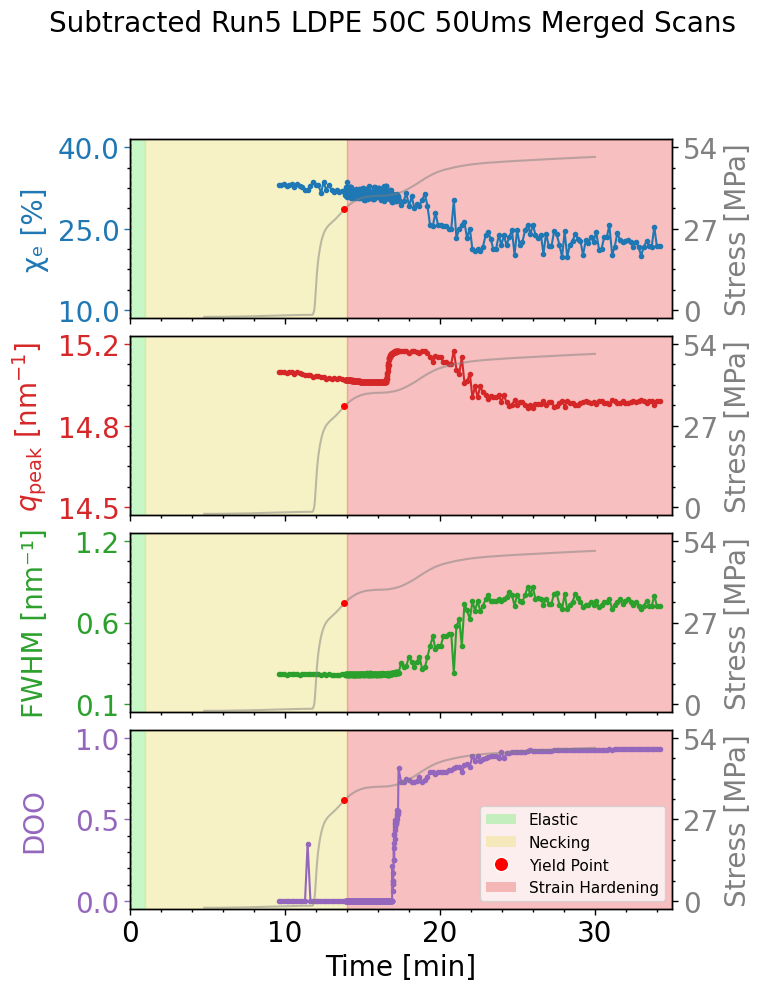

In [12]:
plot_waxs_with_tensile_overlay(
    folder_path_waxs=folder_path_waxs,
    filename_waxs="crystallinity_subtracted_Run5_LDPE_50C_50ums_merged_scans.xlsx",
    filename_waxs_orientation="orientation_Run5_LDPE_50C_50ums_merged_scans.xlsx",
    file_path_tensile=file_path_tensile,
    filename_tensile="Run5_LDPE_50C_50ums 24-05-25 13-30-01-20Exported.xlsx",
    vertical_line_time_str="2025-05-24 13:00:00",
    fonts=20,
    time_mode='relative' , # Change to 'relative' if needed
        time_regions=[
        ("2025-05-24 13:00:00", "2025-05-24 13:1:00", "Elastic", "lightgreen"),
        ("2025-05-24 13:1:00", "2025-05-24 13:14:00", "Necking", "khaki"),
        ("2025-05-24 13:14:00", "2025-05-24 13:35:00", "Strain Hardening", "lightcoral"),
    ],
    yield_point_time_str="2025-05-24 13:13:50",  # <- highlight yield
    y_axis_limits=[
        (10,40),      # χₑ [%]
        (14.5, 15.2), # q_peak [nm⁻¹]
        (0.1, 1.2),   # FWHM [nm⁻¹]
        (0, 1.0)      # DOO
    ]
)

# plot only

In [13]:
import os
import glob

def find_file_by_keyword(folder_path, keyword, ext="xlsx"):
    """
    Search for a file in folder_path containing keyword and return the filename.
    Raises FileNotFoundError if no file is found.
    """
    pattern = os.path.join(folder_path, f"*{keyword}*.{ext}")
    files = glob.glob(pattern)
    
    if len(files) == 0:
        raise FileNotFoundError(f"No file found in {folder_path} matching '{keyword}'")
    
    if len(files) > 1:
        print("Multiple files found, using the first one:", files[0])
    
    return os.path.basename(files[0])  # return only filename, not full path


## 2nd functions

In [14]:
from math import pi
import time
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.dates as mdates
import os
import re
import numpy as np
from scipy.interpolate import interp1d
from matplotlib.ticker import FormatStrFormatter
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

def plot_waxs_with_tensile_overlay(
    folder_path_waxs, filename_waxs, filename_waxs_orientation,
    file_path_tensile, filename_tensile,
    vertical_line_time_str,
    yield_point_time_str=None,    # input for yield point time (string or datetime)
    fonts=16,
    time_mode='absolute',  # 'absolute' or 'relative'
    time_regions=None,     # list of (start_time, end_time, label, color)
    y_axis_limits=None,     # list of (min, max) for each subplot
    cross_sectional_area_mm2=1, # mm^2
    x_time_shift=60 #Sec
):
    # ----------------------
    # Load data
    # ----------------------
    crystallinity_data = extract_WAXS_crystallinity_parameters(folder_path_waxs, filename=filename_waxs)
    orientation_data = extract_WAXS_orientation_parameters(folder_path_waxs, filename=filename_waxs_orientation)

    # Load tensile data
    prop = "Stress"
    x_time, Stress, prop_name = load_linkam_xy_end_ref(file_path_tensile, filename_tensile, prop)
    prop = "Strain"
    x_time, Strain, prop_name = load_linkam_xy_end_ref(file_path_tensile, filename_tensile, prop)

    Stress = Stress / cross_sectional_area_mm2  # Convert force to MPa

    Strain = Strain * 100  # convert to percentage

    x_time = pd.to_datetime(x_time)
    x_time_shifted = x_time - pd.to_timedelta(int(x_time_shift), unit="s")
    x_time = x_time_shifted

    # ----------------------
    # WAXS parameters
    # ----------------------
    date_time = crystallinity_data['percentage_crystallinity'].index
    crystallinity = crystallinity_data['percentage_crystallinity']
    size = crystallinity_data['crystallite_size']
    size = 0.9 * (1.0 / np.array(size)) * 2 * pi  # convert to peak position
    d_spacing = crystallinity_data['d_spacing']
    d_spacing = 2 * pi / d_spacing  # convert d-spacing to peak position

    peak_orientation = orientation_data.get('peak_position_orient')
    fwhm_orientation = orientation_data.get('peak_fwhm_orient')
    DOO = (180 - fwhm_orientation) / 180

    if peak_orientation is None or fwhm_orientation is None:
        raise KeyError("Orientation data missing required columns 'peak_position_orient' or 'peak_fwhm_orient'")
    if len(peak_orientation) != len(date_time):
        raise ValueError("Orientation data length does not match crystallinity data length")

    vertical_line_time = pd.to_datetime(vertical_line_time_str)
    force_color = 'gray'

    # ----------------------
    # Time mode handling
    # ----------------------
    base_time = date_time[0]
    if time_mode == 'relative':
        def to_minutes(t): return (t - base_time).total_seconds() / 60
        date_time = pd.to_datetime(date_time).map(to_minutes)
        x_time = pd.to_datetime(x_time).map(to_minutes)
        vertical_line_time = to_minutes(vertical_line_time)
        if yield_point_time_str is not None:
            yield_point_time = to_minutes(pd.to_datetime(yield_point_time_str))
        else:
            yield_point_time = None
        if time_regions:
            time_regions = [(to_minutes(pd.to_datetime(start)),
                             to_minutes(pd.to_datetime(end)), label, color)
                            for start, end, label, color in time_regions]
        x_label = 'Time [min]'
    else:
        if yield_point_time_str is not None:
            yield_point_time = pd.to_datetime(yield_point_time_str)
        else:
            yield_point_time = None
        x_label = 'WAXS Time'

    # ----------------------
    # Shift time to elastic start
    # ----------------------
    if time_regions and len(time_regions) > 0:
        elastic_start_time = time_regions[0][0]
    else:
        elastic_start_time = date_time.min()

    date_time_shifted = date_time - elastic_start_time
    x_time_shifted = x_time - elastic_start_time
    vertical_line_time_shifted = vertical_line_time - elastic_start_time
    if yield_point_time is not None:
        yield_point_time_shifted = yield_point_time - elastic_start_time
    else:
        yield_point_time_shifted = None
    if time_regions:
        time_regions_shifted = [(start - elastic_start_time, end - elastic_start_time, label, color)
                                for start, end, label, color in time_regions]
    else:
        time_regions_shifted = None

    peak_orientation.index = date_time_shifted
    DOO.index = date_time_shifted

    # ----------------------
    # Plotting
    # ----------------------
    if y_axis_limits is None:
        y_axis_limits = [
            (0, 60),      # χₑ [%]
            (2, 6),       # FWHM [nm⁻¹]
            (0.40, 0.44), # q_peak [nm⁻¹]
            (0.0, 1.0)    # DOO
        ]

    fig, axs = plt.subplots(4, 1, figsize=(7, 10), sharex=True, constrained_layout=False)
    fig.subplots_adjust(hspace=0.1)

    param_info = [
        (crystallinity, 'χₑ [%]', 'tab:blue'),
        (d_spacing, r'$q_{\mathrm{peak}}$ [nm$^{-1}$]', 'tab:red'),
        (size, 'FWHM [nm⁻¹]', 'tab:green'),
        (DOO, 'DOO', 'black'),
    ]

    if yield_point_time_shifted is not None:
        force_interp = interp1d(x_time_shifted, Stress, kind='linear', fill_value='extrapolate')
        force_yield = force_interp(yield_point_time_shifted)

    for i, (data, ylabel, color) in enumerate(param_info):
        ax = axs[i]
        ax.plot(date_time_shifted, data, '.', color=color)
        ax.axvline(x=vertical_line_time_shifted, color='black', linestyle='--', linewidth=1)

        lower, upper = y_axis_limits[i]
        margin = 0.05 * (upper - lower)
        ax.set_ylim(lower - margin, upper + margin)
        ax.set_yticks(np.linspace(*y_axis_limits[i], 3))
        ax.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
        ax.set_ylabel(ylabel)
        ax.yaxis.set_label_coords(-0.15, 0.5)
        ax.tick_params(axis='y', colors=color)
        ax.yaxis.label.set_color(color)

        if time_regions_shifted:
            for start, end, label, region_color in time_regions_shifted:
                ax.axvspan(start, end, color=region_color, alpha=0.5, label=label if i == 0 else None)

        set_plot_style(ax, fonts, '' if i < 3 else x_label, ylabel)

        ax_twin = ax.twinx()
        ax_twin.plot(x_time_shifted, Stress, color=force_color, alpha=0.5, linewidth=1.5)
        set_plot_style(ax_twin, fonts, '', 'Stress [MPa]')
        ymin, ymax = ax_twin.get_ylim()
        ymax_ceil = int(np.ceil(ymax))
        if ymax_ceil % 3 != 0:
            ymax_ceil += 3 - (ymax_ceil % 3)
        ax_twin.set_ylim(0, ymax_ceil)
        ax_twin.set_yticks(np.linspace(0, ymax_ceil, 3))
        margin = 0.05 * (ymax_ceil - 0)
        ax_twin.set_ylim(0 - margin, ymax_ceil + margin)
        ax_twin.tick_params(axis='y', labelcolor=force_color)
        ax_twin.yaxis.label.set_color(force_color)

        if yield_point_time_shifted is not None:
            ax_twin.plot(yield_point_time_shifted, force_yield, 'o', color='red', markersize=4, label='Yield Point' if i == 0 else None)

        ax.grid(False)
        if time_regions_shifted:
            start_time = min(start for start, _, _, _ in time_regions_shifted)
            end_time = max(end for _, end, _, _ in time_regions_shifted)
            ax.set_xlim(start_time, end_time)
        else:
            ax.set_xlim(date_time_shifted.min(), date_time_shifted.max())

        if i == 0:
            elong_start = np.interp(0, x_time_shifted, Strain)
            elong_shifted = Strain - elong_start
            time_vals = np.array(x_time_shifted)
            elong_vals = np.array(elong_shifted)
            interp_func = interp1d(time_vals, elong_vals, kind='linear', fill_value='extrapolate')
            inv_interp_func = interp1d(elong_vals, time_vals, kind='linear', fill_value='extrapolate')
            def time_to_elong(x):
                return interp_func(x)
            def elong_to_time(x):
                return inv_interp_func(x)
            ax_top = ax.secondary_xaxis('top', functions=(time_to_elong, elong_to_time))
            ax_top.tick_params(axis='x', labelsize=fonts)
            ax_top.minorticks_on()
            set_plot_style(ax_top, fonts, 'Elongation [%]', '')
            ax_top.set_xlabel('Elongation [%]', fontsize=fonts, labelpad=10)
            min_elong = 0
            max_elong = 475
            ax_top.set_xlim(min_elong, max_elong)
            ax_top.set_xticks(np.linspace(min_elong, max_elong, num=6))
            ax_top.xaxis.set_major_formatter(FormatStrFormatter('%.0f'))

    if time_mode == 'absolute':
        axs[-1].xaxis.set_major_formatter(FormatStrFormatter('%.1f'))
        axs[-1].tick_params(axis='x', labelsize=fonts)

    # ----------------------
    # Legend
    # ----------------------
    '''
    desired_order = ['elastic', 'necking', 'yield point', 'strain hardening']
    legend_patches = []
    region_patch_dict = {}
    if time_regions_shifted:
        for _, _, label, color in time_regions_shifted:
            region_patch_dict[label.lower()] = Patch(facecolor=color, edgecolor=None, alpha=0.5, label=label, linestyle=None)
    for label in desired_order:
        lower_label = label.lower()
        if lower_label == 'yield point':
            yield_legend = Line2D([0], [0], marker='o', color='w', label='Yield Point',
                                markerfacecolor='red', markersize=16, linestyle='None')
            legend_patches.append(yield_legend)
        else:
            for key, patch in region_patch_dict.items():
                if lower_label in key:
                    legend_patches.append(patch)
                    break
    if legend_patches:
        axs[-1].legend(handles=legend_patches, loc='lower right', fontsize=fonts*0.55,
                       frameon=True, markerscale=0.65, framealpha=0.75)
    '''
    filename_base = os.path.splitext(filename_waxs)[0]
    title_clean = filename_base.replace('_', ' ').replace('-', ' ').title()
    title_clean = re.sub(r'\bCrystallinity\b', '', title_clean, flags=re.IGNORECASE).strip()
    title_clean = re.sub(r'\b(Ldpe|P5Hv|Phpd|P3HB|PHA-3B)\b', lambda m: m.group(0).upper(), title_clean)
    plt.suptitle(f"{title_clean}", fontsize=fonts, weight='normal', y=1.01)

    # ----------------------
    # Save two sheets to Excel
    # ----------------------
    if time_mode == 'absolute':
        tensile_duration_min = (x_time_shifted.max() - x_time_shifted.min()).total_seconds() / 60
        waxs_duration_min = (date_time_shifted.max() - date_time_shifted.min()).total_seconds() / 60
    else:  # relative mode, already in minutes as floats
        tensile_duration_min = float(x_time_shifted.max() - x_time_shifted.min())
        waxs_duration_min = float(date_time_shifted.max() - date_time_shifted.min())

    tensile_df = pd.DataFrame({
        "Time": x_time_shifted,
        "Stress [MPa]": Stress,
        "Strain [%]": Strain
    })
    waxs_df = pd.DataFrame({
        "Time": date_time_shifted,
        "Crystallinity [%]": crystallinity.values if hasattr(crystallinity, 'values') else crystallinity,
        "Peak Position [nm^-1]": d_spacing,
        "FWHM [nm^-1]": size,
        "DOO": DOO.values if hasattr(DOO, 'values') else DOO
    })

    # Save to Excel creating new folder to save the results
    folder_path_waxs = os.path.join(folder_path_waxs, "Processed")
    
    if not os.path.exists(folder_path_waxs):
        os.makedirs(folder_path_waxs)
    
    # remove crytallinity_subtracted_ or orientation_ from filename base
    filename_base = re.sub(r'^(crystallinity_subtracted_|orientation_)', '', filename_base, flags=re.IGNORECASE)
    out_filename = 'Tensile_WAXS_'+ filename_base + "_processed.xlsx"
    out_path = os.path.join(folder_path_waxs, out_filename)

    with pd.ExcelWriter(out_path, engine="openpyxl") as writer:
        tensile_df.to_excel(writer, sheet_name="Tensile", index=False)
        waxs_df.to_excel(writer, sheet_name="WAXS", index=False)

    print(f"\nResults saved to: {out_path}")


    # ----------------------
    # Save figure as SVG in same folder
    # ----------------------
    svg_filename = 'Tensile_WAXS_' + filename_base + "_processed.svg"
    svg_path = os.path.join(folder_path_waxs, svg_filename)
    plt.savefig(svg_path, format='svg', bbox_inches='tight')
    print(f"Figure saved as SVG to: {svg_path}")


## LDPE


📂 Processing file: crystallinity_subtracted_Run8_LDPE_30C_50ums_merged_scans.xlsx

📂 Processing file: orientation_Run8_LDPE_30C_50ums_merged_scans.xlsx

Results saved to: /Volumes/SSD1/RawData1/Redesigned_Plastics/May2025/2025_05_Anjani/OneD_integrated_WAXS_01/Subtracted_Data/Final_analysis/Processed/Tensile_WAXS_Run8_LDPE_30C_50ums_merged_scans_processed.xlsx


/Applications/anaconda3/envs/bl17_2/lib/python3.12/site-packages/scipy/interpolate/_interpolate.py:479: RuntimeWarning: divide by zero encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
/Applications/anaconda3/envs/bl17_2/lib/python3.12/site-packages/scipy/interpolate/_interpolate.py:482: RuntimeWarning: invalid value encountered in multiply
  y_new = slope*(x_new - x_lo)[:, None] + y_lo


Figure saved as SVG to: /Volumes/SSD1/RawData1/Redesigned_Plastics/May2025/2025_05_Anjani/OneD_integrated_WAXS_01/Subtracted_Data/Final_analysis/Processed/Tensile_WAXS_Run8_LDPE_30C_50ums_merged_scans_processed.svg

📂 Processing file: crystallinity_subtracted_Run5_LDPE_50C_50ums_merged_scans.xlsx

📂 Processing file: orientation_Run5_LDPE_50C_50ums_merged_scans.xlsx

Results saved to: /Volumes/SSD1/RawData1/Redesigned_Plastics/May2025/2025_05_Anjani/OneD_integrated_WAXS_01/Subtracted_Data/Final_analysis/Processed/Tensile_WAXS_Run5_LDPE_50C_50ums_merged_scans_processed.xlsx
Figure saved as SVG to: /Volumes/SSD1/RawData1/Redesigned_Plastics/May2025/2025_05_Anjani/OneD_integrated_WAXS_01/Subtracted_Data/Final_analysis/Processed/Tensile_WAXS_Run5_LDPE_50C_50ums_merged_scans_processed.svg

📂 Processing file: crystallinity_subtracted_Run6_LDPE_75C_50ums_merged_scans.xlsx

📂 Processing file: orientation_Run6_LDPE_75C_50ums_merged_scans.xlsx


/Applications/anaconda3/envs/bl17_2/lib/python3.12/site-packages/scipy/interpolate/_interpolate.py:479: RuntimeWarning: divide by zero encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
/Applications/anaconda3/envs/bl17_2/lib/python3.12/site-packages/scipy/interpolate/_interpolate.py:482: RuntimeWarning: invalid value encountered in multiply
  y_new = slope*(x_new - x_lo)[:, None] + y_lo



Results saved to: /Volumes/SSD1/RawData1/Redesigned_Plastics/May2025/2025_05_Anjani/OneD_integrated_WAXS_01/Subtracted_Data/Final_analysis/Processed/Tensile_WAXS_Run6_LDPE_75C_50ums_merged_scans_processed.xlsx
Figure saved as SVG to: /Volumes/SSD1/RawData1/Redesigned_Plastics/May2025/2025_05_Anjani/OneD_integrated_WAXS_01/Subtracted_Data/Final_analysis/Processed/Tensile_WAXS_Run6_LDPE_75C_50ums_merged_scans_processed.svg

📂 Processing file: crystallinity_subtracted_Run7_LDPE_100C_50ums_merged_scans.xlsx


/Applications/anaconda3/envs/bl17_2/lib/python3.12/site-packages/scipy/interpolate/_interpolate.py:479: RuntimeWarning: divide by zero encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
/Applications/anaconda3/envs/bl17_2/lib/python3.12/site-packages/scipy/interpolate/_interpolate.py:482: RuntimeWarning: invalid value encountered in multiply
  y_new = slope*(x_new - x_lo)[:, None] + y_lo



📂 Processing file: orientation_Run7_LDPE_100C_50ums_merged_scans.xlsx

Results saved to: /Volumes/SSD1/RawData1/Redesigned_Plastics/May2025/2025_05_Anjani/OneD_integrated_WAXS_01/Subtracted_Data/Final_analysis/Processed/Tensile_WAXS_Run7_LDPE_100C_50ums_merged_scans_processed.xlsx
Figure saved as SVG to: /Volumes/SSD1/RawData1/Redesigned_Plastics/May2025/2025_05_Anjani/OneD_integrated_WAXS_01/Subtracted_Data/Final_analysis/Processed/Tensile_WAXS_Run7_LDPE_100C_50ums_merged_scans_processed.svg


/Applications/anaconda3/envs/bl17_2/lib/python3.12/site-packages/scipy/interpolate/_interpolate.py:479: RuntimeWarning: divide by zero encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
/Applications/anaconda3/envs/bl17_2/lib/python3.12/site-packages/scipy/interpolate/_interpolate.py:482: RuntimeWarning: invalid value encountered in multiply
  y_new = slope*(x_new - x_lo)[:, None] + y_lo


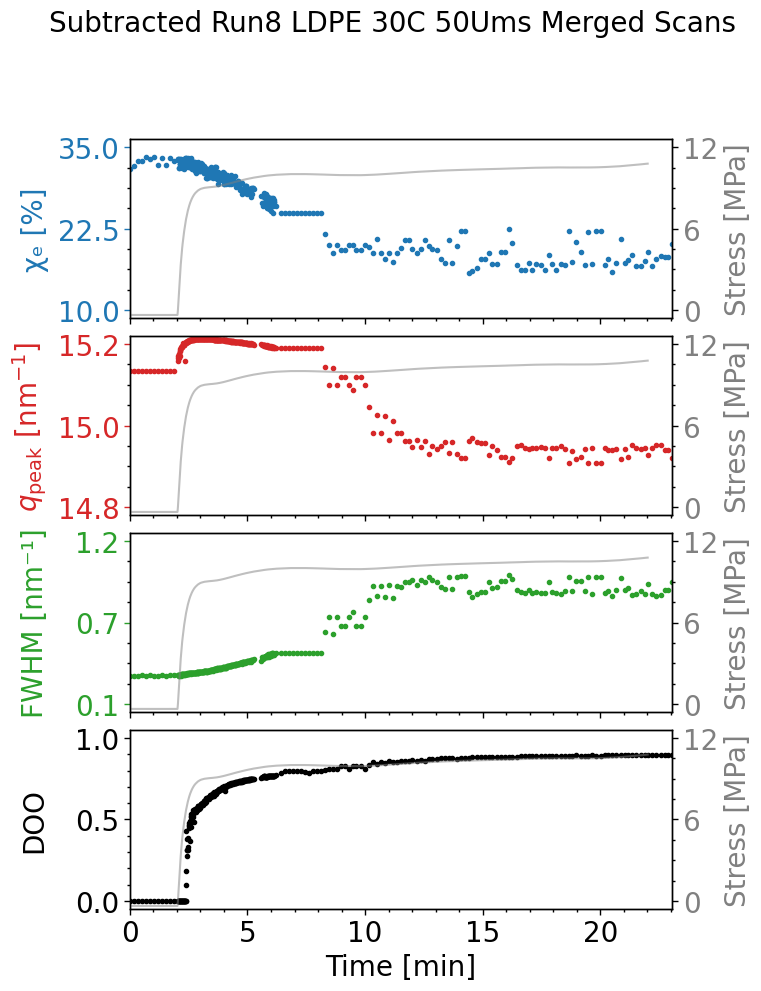

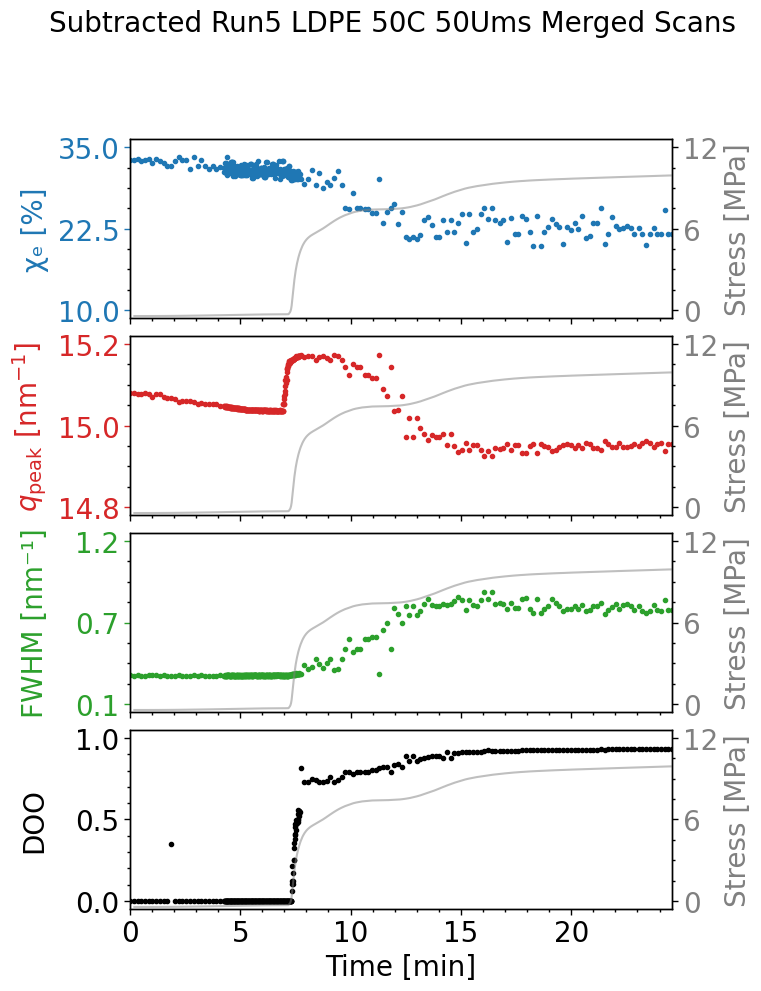

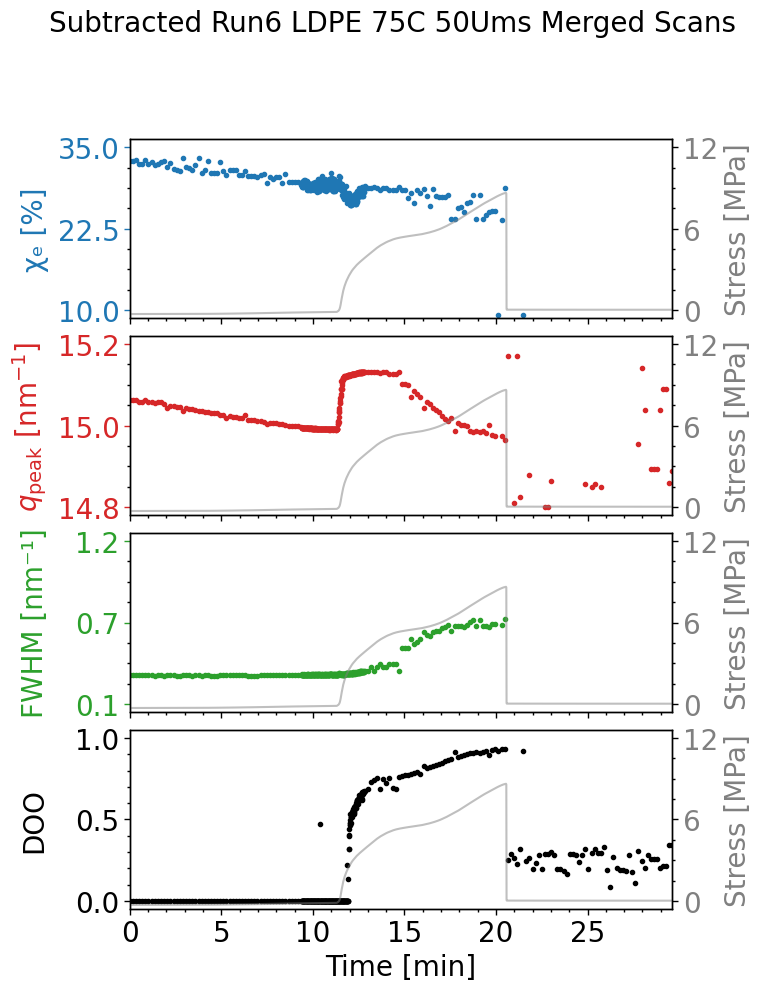

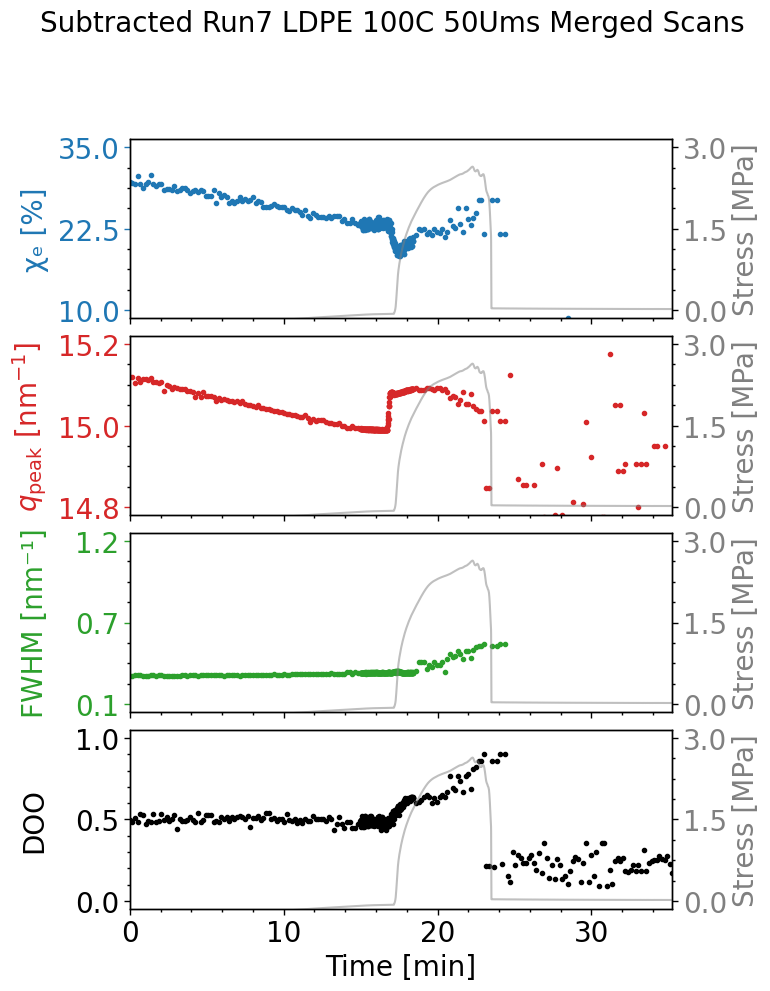

In [15]:
runs_and_shifts = [
    ("Run8_LDPE_30C_50ums", -110),
    ("Run5_LDPE_50C_50ums", -300),
    ("Run6_LDPE_75C_50ums", -630),
    ("Run7_LDPE_100C_50ums", -1000),
]

y_axis_limits = [
    (10, 35),     # χₑ [%]
    (14.8, 15.2), # q_peak [nm⁻¹]
    (0.1, 1.25),   # FWHM [nm⁻¹]
    (0, 1.0),   # DOO
]

for run, x_shift in runs_and_shifts:
    filename_tensile = find_file_by_keyword(file_path_tensile, run)
    plot_waxs_with_tensile_overlay(
        folder_path_waxs=folder_path_waxs,
        filename_waxs=f"crystallinity_subtracted_{run}_merged_scans.xlsx",
        filename_waxs_orientation=f"orientation_{run}_merged_scans.xlsx",
        file_path_tensile=file_path_tensile,
        filename_tensile=filename_tensile,
        vertical_line_time_str="2025-05-24 13:00:00",
        fonts=20,
        time_mode="relative",
        y_axis_limits=y_axis_limits,
        cross_sectional_area_mm2=10*0.51,  # mm^2
        x_time_shift=x_shift
    )


## PHPD


📂 Processing file: crystallinity_subtracted_Run9_PHPD_30C_50ums_merged_scans.xlsx

📂 Processing file: orientation_Run9_PHPD_30C_50ums_merged_scans.xlsx

Results saved to: /Volumes/SSD1/RawData1/Redesigned_Plastics/May2025/2025_05_Anjani/OneD_integrated_WAXS_01/Subtracted_Data/Final_analysis/Processed/Tensile_WAXS_Run9_PHPD_30C_50ums_merged_scans_processed.xlsx
Figure saved as SVG to: /Volumes/SSD1/RawData1/Redesigned_Plastics/May2025/2025_05_Anjani/OneD_integrated_WAXS_01/Subtracted_Data/Final_analysis/Processed/Tensile_WAXS_Run9_PHPD_30C_50ums_merged_scans_processed.svg

📂 Processing file: crystallinity_subtracted_Run10_PHPD_45C_50ums_merged_scans.xlsx

📂 Processing file: orientation_Run10_PHPD_45C_50ums_merged_scans.xlsx


/Applications/anaconda3/envs/bl17_2/lib/python3.12/site-packages/scipy/interpolate/_interpolate.py:479: RuntimeWarning: divide by zero encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
/Applications/anaconda3/envs/bl17_2/lib/python3.12/site-packages/scipy/interpolate/_interpolate.py:482: RuntimeWarning: invalid value encountered in multiply
  y_new = slope*(x_new - x_lo)[:, None] + y_lo



Results saved to: /Volumes/SSD1/RawData1/Redesigned_Plastics/May2025/2025_05_Anjani/OneD_integrated_WAXS_01/Subtracted_Data/Final_analysis/Processed/Tensile_WAXS_Run10_PHPD_45C_50ums_merged_scans_processed.xlsx
Figure saved as SVG to: /Volumes/SSD1/RawData1/Redesigned_Plastics/May2025/2025_05_Anjani/OneD_integrated_WAXS_01/Subtracted_Data/Final_analysis/Processed/Tensile_WAXS_Run10_PHPD_45C_50ums_merged_scans_processed.svg

📂 Processing file: crystallinity_subtracted_Run11_PHPD_60C_50ums_merged_scans.xlsx

📂 Processing file: orientation_Run11_PHPD_60C_50ums_merged_scans.xlsx

Results saved to: /Volumes/SSD1/RawData1/Redesigned_Plastics/May2025/2025_05_Anjani/OneD_integrated_WAXS_01/Subtracted_Data/Final_analysis/Processed/Tensile_WAXS_Run11_PHPD_60C_50ums_merged_scans_processed.xlsx
Figure saved as SVG to: /Volumes/SSD1/RawData1/Redesigned_Plastics/May2025/2025_05_Anjani/OneD_integrated_WAXS_01/Subtracted_Data/Final_analysis/Processed/Tensile_WAXS_Run11_PHPD_60C_50ums_merged_scans_pro

/Applications/anaconda3/envs/bl17_2/lib/python3.12/site-packages/scipy/interpolate/_interpolate.py:479: RuntimeWarning: divide by zero encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
/Applications/anaconda3/envs/bl17_2/lib/python3.12/site-packages/scipy/interpolate/_interpolate.py:482: RuntimeWarning: invalid value encountered in multiply
  y_new = slope*(x_new - x_lo)[:, None] + y_lo


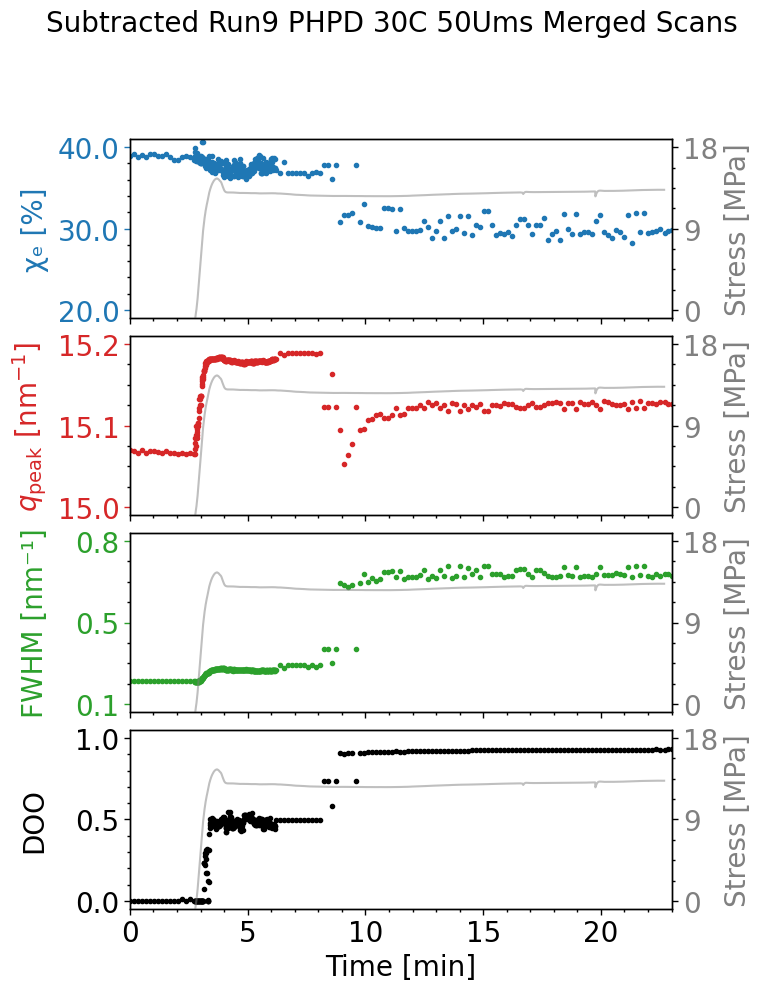

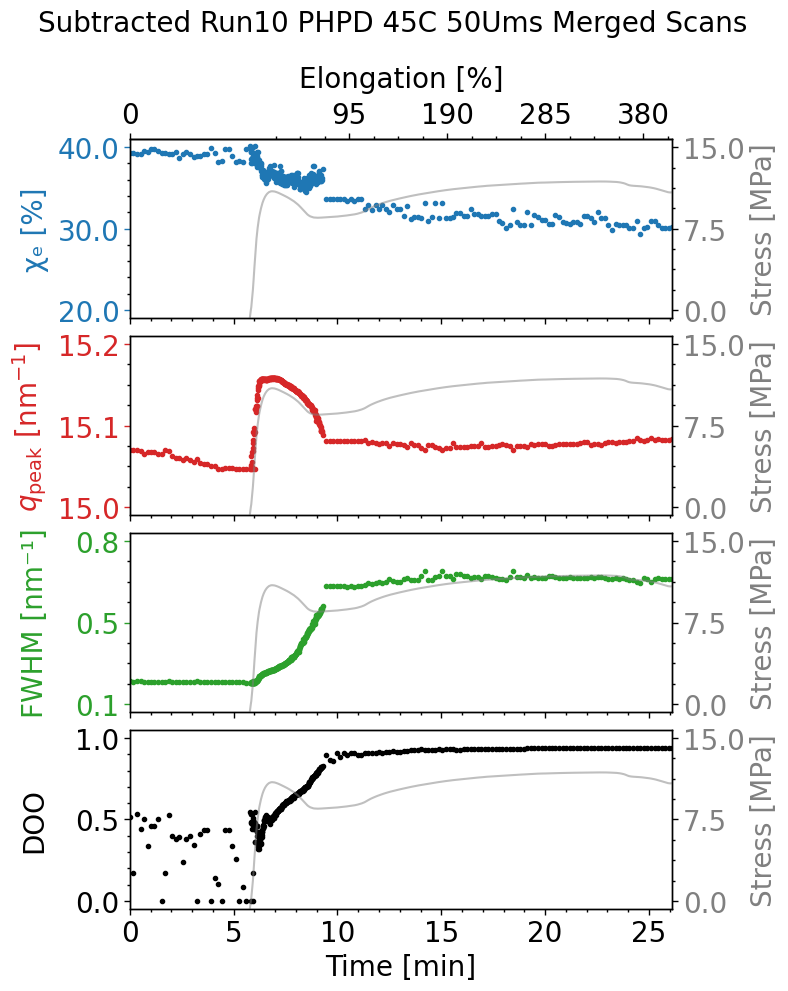

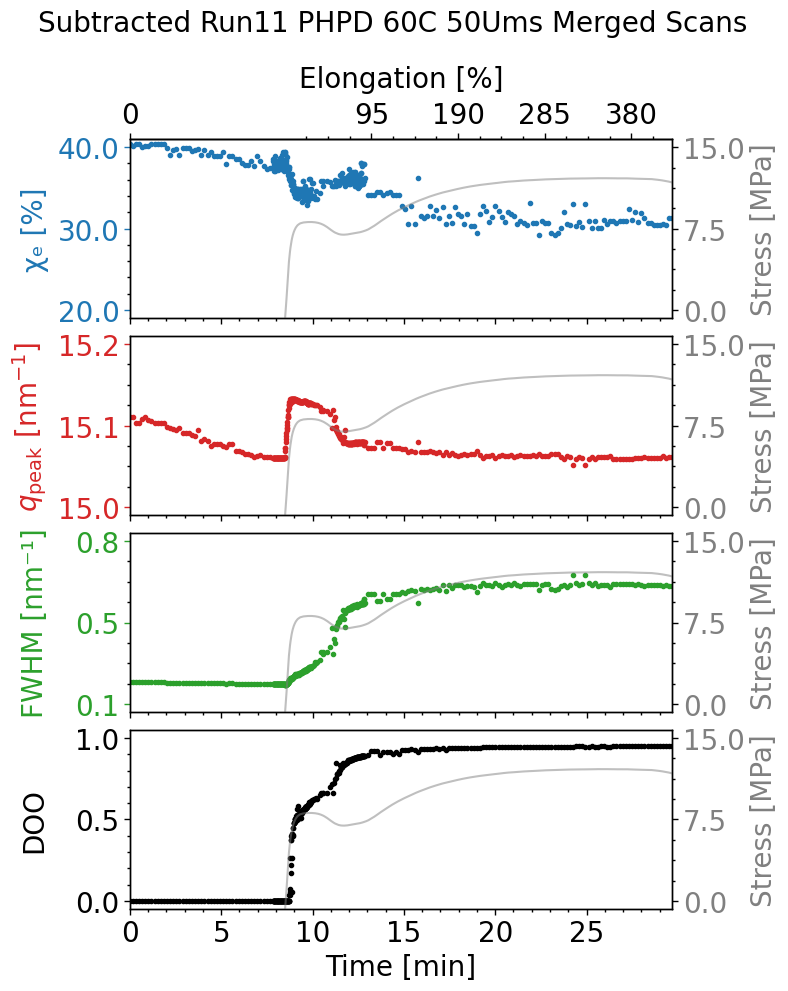

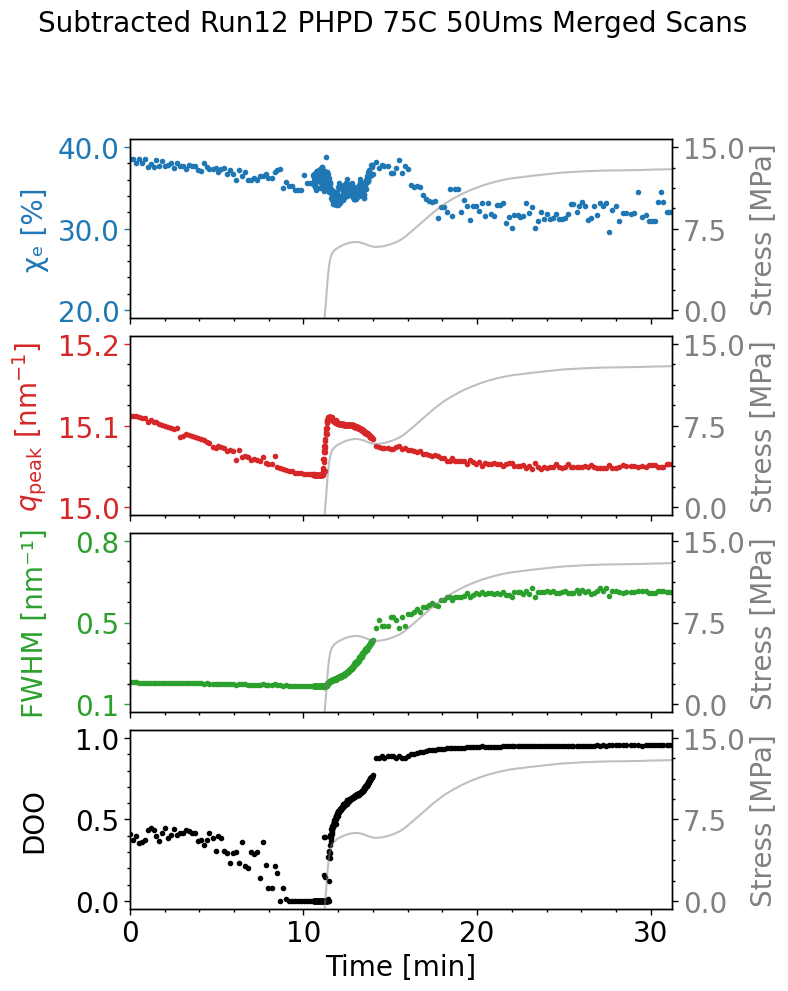

In [16]:
runs_and_shifts = [
    ("Run9_PHPD_30C_50ums", -190),
    ("Run10_PHPD_45C_50ums", -410),
    ("Run11_PHPD_60C_50ums", -650),
    ("Run12_PHPD_75C_50ums", -830),
]


y_axis_limits = [
    (20, 40),     # χₑ [%]
    (15.0, 15.25), # q_peak [nm⁻¹]
    (0.1, 0.8),   # FWHM [nm⁻¹]
    (0, 1.0),   # DOO
]


for run, x_shift in runs_and_shifts:
    filename_tensile = find_file_by_keyword(file_path_tensile, run)
    plot_waxs_with_tensile_overlay(
        folder_path_waxs=folder_path_waxs,
        filename_waxs=f"crystallinity_subtracted_{run}_merged_scans.xlsx",
        filename_waxs_orientation=f"orientation_{run}_merged_scans.xlsx",
        file_path_tensile=file_path_tensile,
        filename_tensile=filename_tensile,
        vertical_line_time_str="2025-05-24 13:00:00",
        fonts=20,
        time_mode="relative",
        y_axis_limits=y_axis_limits,
        cross_sectional_area_mm2=10*1.045,  # mm^2
        x_time_shift=x_shift
    )
